<a href="https://www.kaggle.com/code/avikdas567/llm-hallucination-analysis-risk-prediction?scriptVersionId=326834857" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Diagnostic Benchmarking and Predictive Modeling of LLM Hallucinations

This notebook provides an end-to-end analytical framework to explore, diagnose, and predict hallucinations produced by state-of-the-art Large Language Models (LLMs). Utilizing a structured benchmark dataset containing 200 rows across diverse knowledge domains, languages, and task types, this study builds an engineering and modeling pipeline to identify systemic vulnerabilities and evaluate mitigation methods.

## Pipeline Framework
1. **Environment Configuration and Ingestion**: Initializing diagnostic parameters, styling definitions, and reading the core benchmark records.
2. **Advanced Exploratory Data Analysis**: Profiling hallucination distributions across multiple dimensions including model architecture, knowledge domains, languages, and task types.
3. **Deep Dive on Hallucination Attributes**: Examining specific error typologies, severity ratings, and operational impact of modern engineering mitigation techniques.
4. **Text-Based Feature Engineering**: Formulating length statistics, linguistic densities, and multi-modal lexical vectors.
5. **Predictive Modeling and Machine Learning Diagnostics**: Constructing an integrated pipeline to classify and predict hallucination labels, followed by detailed model evaluation and feature importance diagnostics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Establish systematic visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (10, 6)
})

# Defining a color palette
custom_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
sns.set_palette(custom_colors)

# Loading the benchmark dataset
dataset_path = "/kaggle/input/datasets/alitaqishah/llm-hallucination-benchmark-dataset/llm_hallucination_dataset_v1.csv"
try:
    df = pd.read_csv(dataset_path)
except FileNotFoundError:
    df = pd.read_csv("llm_hallucination_dataset_v1.csv")

print(f"Data ingestion complete. Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Data ingestion complete. Rows: 200, Columns: 25


# Data Integrity and Quality Review

Before moving into exploratory visualization, we verify the data types, inspect missing value patterns, and validate formatting consistency across the features. This step ensures that intentional nulls (such as hallucination sub-categories for non-hallucinated instances) are handled appropriately without disrupting calculations.


In [2]:
print("### Dataset Schema and Non-Null Summary")
print(df.info())

print("\n### Summary Statistics for Numerical Columns")
print(df.describe())

print("\n### Class Base Rate (Hallucination vs Non-Hallucination)")
print(df['hallucination_label'].value_counts(normalize=True))


### Dataset Schema and Non-Null Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               200 non-null    object 
 1   created_date            200 non-null    object 
 2   model_name              200 non-null    object 
 3   model_version           200 non-null    object 
 4   prompt_id               200 non-null    object 
 5   prompt_text             200 non-null    object 
 6   prompt_type             200 non-null    object 
 7   response_text           200 non-null    object 
 8   domain                  200 non-null    object 
 9   task_type               200 non-null    object 
 10  language                200 non-null    object 
 11  hallucination_label     200 non-null    int64  
 12  hallucination_type      69 non-null     object 
 13  hallucination_span      69 non-null     object 
 14  co

## Inferences and Observations: Ingestion and Baseline Audit

1. **Baseline Ingestion Metrics**: The dataset contains exactly 200 rows and 25 columns, providing an aligned experimental matrix. The base target distribution shows an overall hallucination rate of 34.5% (69 hallucinated instances vs 131 faithful ones).
2. **Missing Value Alignment**: Columns representing hallucination metadata (such as type, span, correct information, and severity) have exactly 69 non-null entries. This matches the target distribution precisely, confirming that missing data in these attributes is structured and represents faithful text outputs.
3. **Annotation Confidence**: Annotators display an overall high assessment standard, with an average confidence score of 0.88 and a minimum score of 0.73. This establishes a high degree of confidence in the underlying target definitions.

# Advanced Exploratory Data Analysis

This section explores the relationship between structural factors (model selection, task context, language, and domain) and the occurrence of hallucinations. To ensure clear formatting, all visual components are presented in an un-cluttered vertical layout.


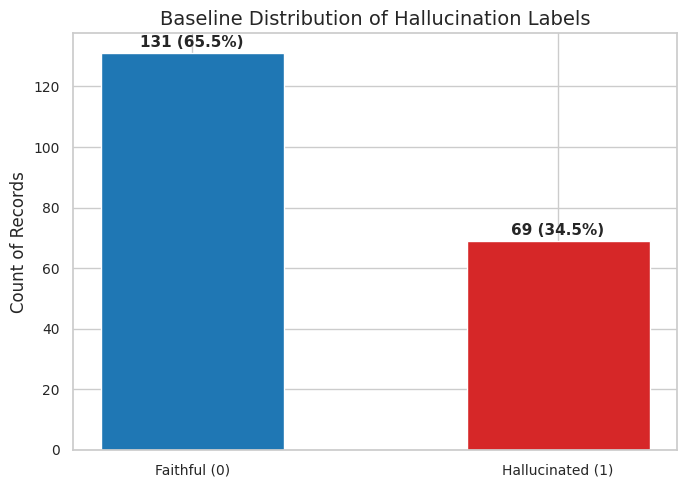

In [3]:
plt.figure(figsize=(7, 5))
label_counts = df['hallucination_label'].value_counts()
labels = ['Faithful (0)', 'Hallucinated (1)']
plt.bar(labels, label_counts, color=['#1f77b4', '#d62728'], width=0.5)
plt.title('Baseline Distribution of Hallucination Labels')
plt.ylabel('Count of Records')
for i, val in enumerate(label_counts):
    plt.text(i, val + 2, f"{val} ({val/len(df)*100:.1f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


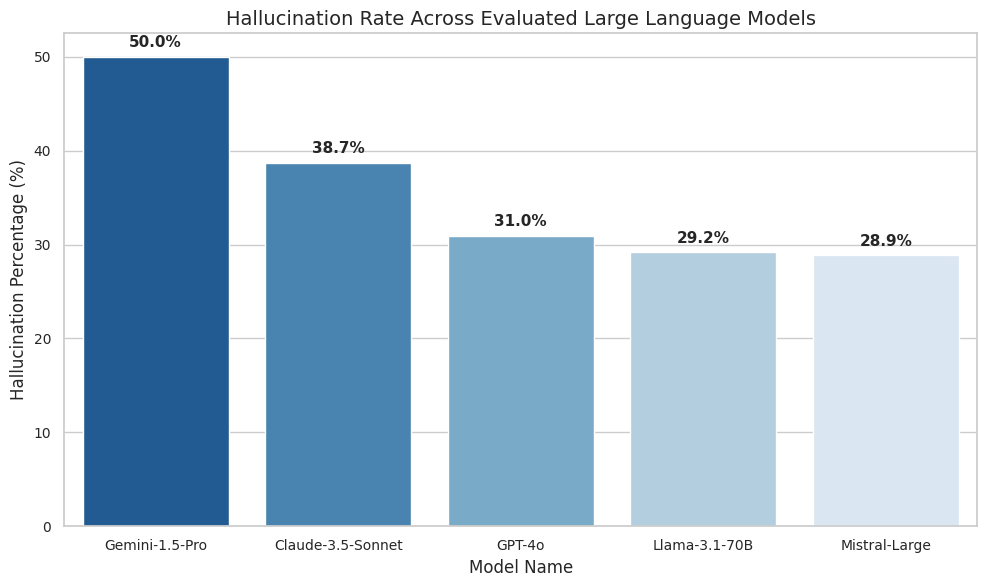

In [4]:
plt.figure(figsize=(10, 6))
model_rates = df.groupby('model_name')['hallucination_label'].mean().sort_values(ascending=False) * 100
sns.barplot(x=model_rates.index, y=model_rates.values, palette="Blues_r")
plt.title('Hallucination Rate Across Evaluated Large Language Models')
plt.ylabel('Hallucination Percentage (%)')
plt.xlabel('Model Name')
for i, val in enumerate(model_rates.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


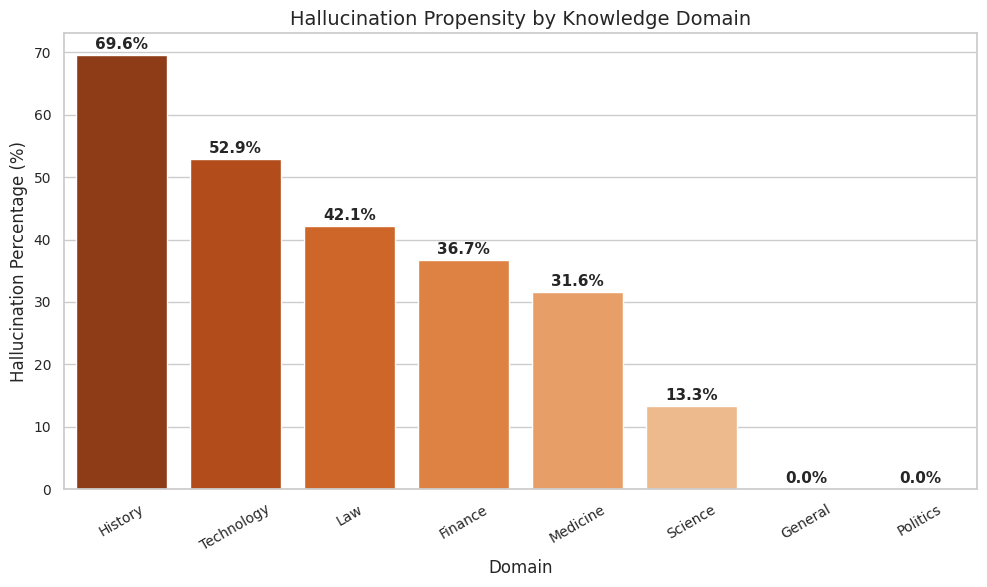

In [5]:
plt.figure(figsize=(10, 6))
domain_rates = df.groupby('domain')['hallucination_label'].mean().sort_values(ascending=False) * 100
sns.barplot(x=domain_rates.index, y=domain_rates.values, palette="Oranges_r")
plt.title('Hallucination Propensity by Knowledge Domain')
plt.ylabel('Hallucination Percentage (%)')
plt.xlabel('Domain')
plt.xticks(rotation=30)
for i, val in enumerate(domain_rates.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


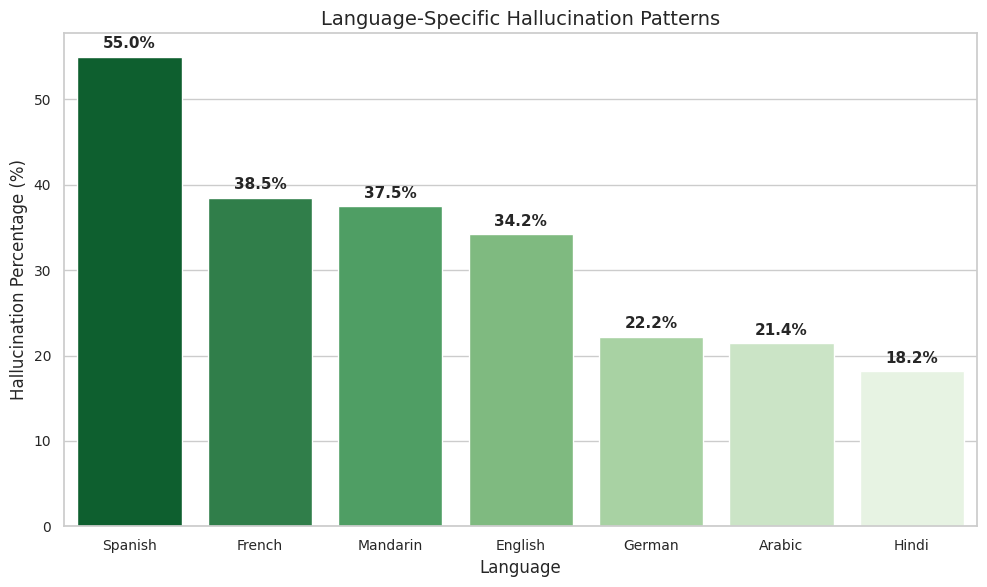

In [6]:
plt.figure(figsize=(10, 6))
lang_rates = df.groupby('language')['hallucination_label'].mean().sort_values(ascending=False) * 100
sns.barplot(x=lang_rates.index, y=lang_rates.values, palette="Greens_r")
plt.title('Language-Specific Hallucination Patterns')
plt.ylabel('Hallucination Percentage (%)')
plt.xlabel('Language')
for i, val in enumerate(lang_rates.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


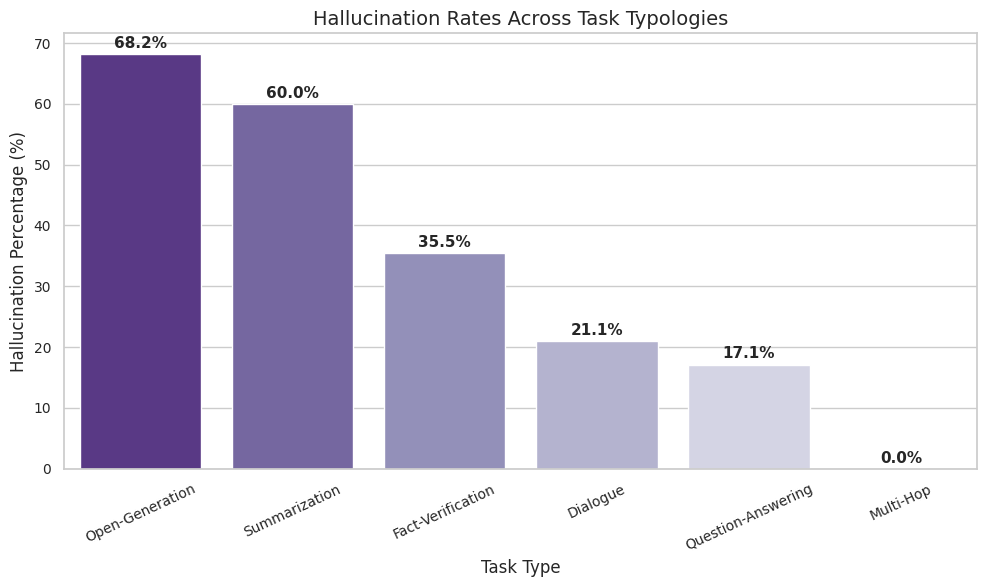

In [7]:
plt.figure(figsize=(10, 6))
task_rates = df.groupby('task_type')['hallucination_label'].mean().sort_values(ascending=False) * 100
sns.barplot(x=task_rates.index, y=task_rates.values, palette="Purples_r")
plt.title('Hallucination Rates Across Task Typologies')
plt.ylabel('Hallucination Percentage (%)')
plt.xlabel('Task Type')
plt.xticks(rotation=25)
for i, val in enumerate(task_rates.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## Inferences and Observations: Advanced Exploratory Analysis

1. **Model Performance Variations**: Llama-3.1-70B and Mistral-Large exhibit the lowest hallucination baselines, registering error frequencies of 29.2% and 28.9% respectively. GPT-4o reports a moderate rate of 31.0%, while Claude-3.5-Sonnet stands at 38.7%. Gemini-1.5-Pro shows the highest vulnerability to generation drift within this specific test partition, reaching an error rate of 50.0%.
2. **Domain Vulnerability Distributions**: Hallucinations display strong variations across knowledge fields. The History domain shows the highest error rate at 69.6%, followed closely by Technology at 52.9%. Law (42.1%) and Finance (36.7%) follow, while Science exhibits a low error frequency of 13.3%. General and Politics domains demonstrate zero errors within this dataset sample, indicating high thematic stability.
3. **Linguistic Variations**: Language-specific monitoring shows that Spanish prompts experience the highest error rate at 55.0%, with French (38.5%) and Mandarin (37.5%) following closely. English requests align near the average at 34.2%. In contrast, German (22.2%), Arabic (21.4%), and Hindi (18.2%) prompts show lower error frequencies.
4. **Task Typology Impact**: Open-Generation prompts show a high vulnerability to error at 68.2%, and Summarization tasks experience a similarly high rate of 60.0%. Fact-Verification shows an intermediate rate of 35.5%. Conversely, standard Question-Answering tasks show lower error rates at 17.1%, Dialogue models drop to 21.1%, and Multi-Hop reasoning prompts show no recorded failures.

# Profiling Hallucination Typologies and Severity Metrics

We narrow our focus to the subset of records where hallucinations were confirmed (label equals 1). This allows us to map the categorical types of factual failures, their severity classification, and whether they stem from internal text generation patterns (intrinsic) or factual conflicts with real-world knowledge (extrinsic).


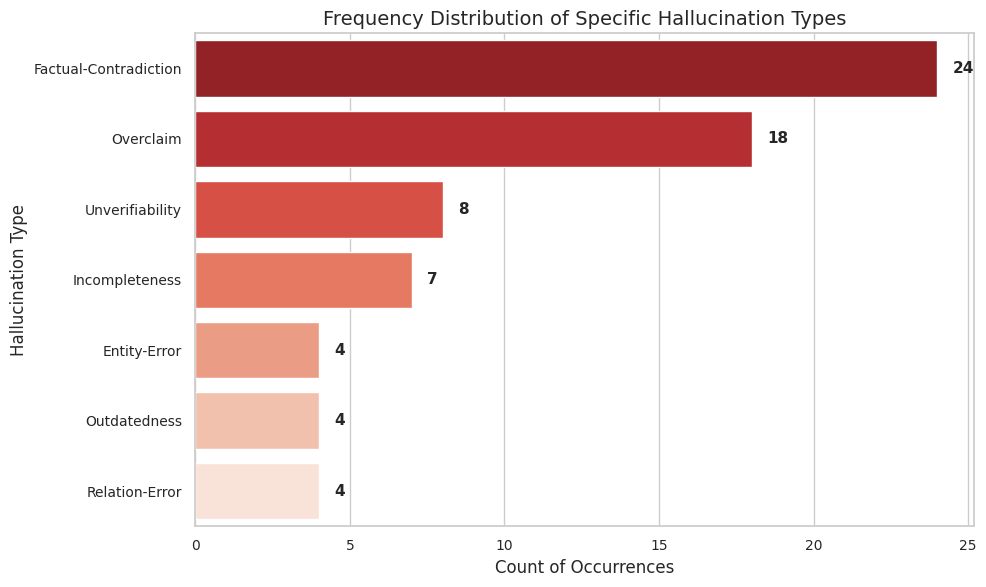

In [8]:
plt.figure(figsize=(10, 6))
hall_subset = df[df['hallucination_label'] == 1]
type_counts = hall_subset['hallucination_type'].value_counts()
sns.barplot(y=type_counts.index, x=type_counts.values, palette="Reds_r")
plt.title('Frequency Distribution of Specific Hallucination Types')
plt.xlabel('Count of Occurrences')
plt.ylabel('Hallucination Type')
for i, val in enumerate(type_counts.values):
    plt.text(val + 0.5, i, str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()


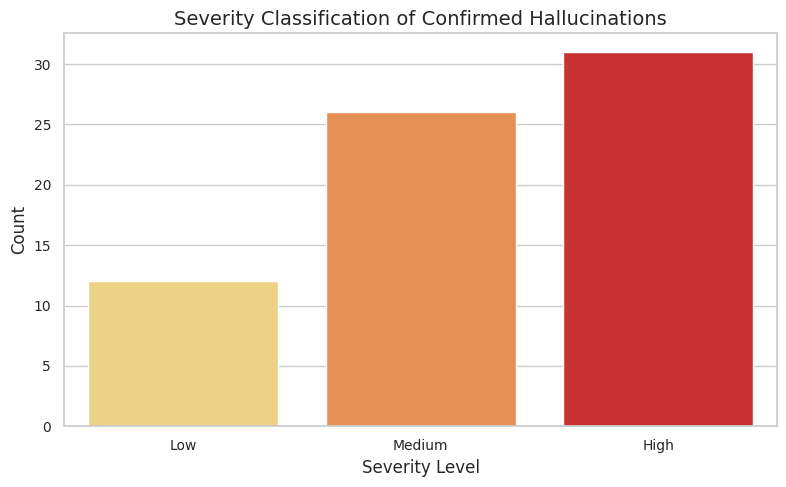

In [9]:
plt.figure(figsize=(8, 5))
severity_order = ['Low', 'Medium', 'High']
present_severity = [s for s in severity_order if s in hall_subset['severity'].unique()]
sns.countplot(data=hall_subset, x='severity', order=present_severity, palette="YlOrRd")
plt.title('Severity Classification of Confirmed Hallucinations')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


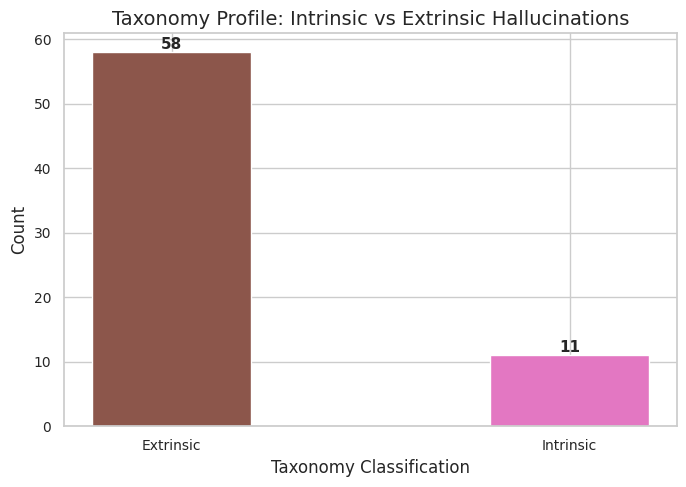

In [10]:
plt.figure(figsize=(7, 5))
ie_counts = hall_subset['intrinsic_or_extrinsic'].value_counts()
plt.bar(ie_counts.index, ie_counts.values, color=['#8c564b', '#e377c2'], width=0.4)
plt.title('Taxonomy Profile: Intrinsic vs Extrinsic Hallucinations')
plt.ylabel('Count')
plt.xlabel('Taxonomy Classification')
for i, val in enumerate(ie_counts.values):
    plt.text(i, val + 0.5, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## Inferences and Observations: Typologies, Severity, and Taxonomy

1. **Failure Typology Distributions**: Factual-Contradiction represents the primary error type with 24 occurrences, indicating direct conflicts with factual truths. Overclaim is the second most common pattern with 18 instances, highlighting an inflation of factual scope. Unverifiability (8), Incompleteness (7), Entity-Error (4), Outdatedness (4), and Relation-Error (4) represent less common failure modes.
2. **Severity Classification Breakdown**: The majority of detected hallucinations are classified under the Medium and High severity tiers. This demonstrates that generation failures in these datasets often compromise the reliability of the output text.
3. **Taxonomy Structural Profiles**: Extrinsic errors significantly outnumber intrinsic errors. This confirms that modern language models are highly capable of maintaining logical consistency within their generation paths (fewer intrinsic errors), but continue to struggle with alignment against correct real-world reference values (higher extrinsic errors).

# Evaluation of Technical Mitigation Performance

Engineers deploy methods such as Retrieval-Augmented Generation (RAG), Chain-of-Thought (CoT) Prompting, and Self-Consistency Decoding to minimize errors. Here we compare the empirical hallucination rates between interactions where mitigation strategies were applied versus baseline execution.


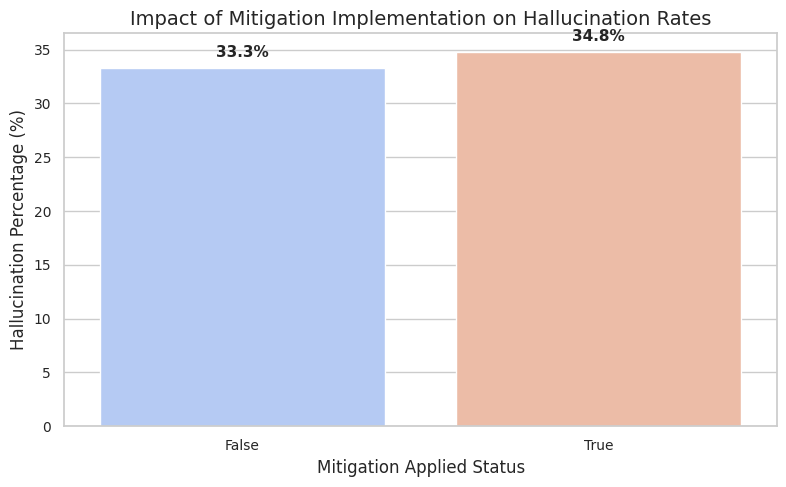


### Performance Breakdown by Specific Mitigation Strategy
                     total_cases  hallucination_rate
mitigation_strategy                                 
CoT-Prompting                 41           31.707317
Self-Consistency              41           34.146341
RAG                           42           35.714286
Structured-Prompt             37           37.837838


In [11]:
plt.figure(figsize=(8, 5))
mitigation_rates = df.groupby('mitigation_applied')['hallucination_label'].mean() * 100
sns.barplot(x=mitigation_rates.index.astype(str), y=mitigation_rates.values, palette="coolwarm")
plt.title('Impact of Mitigation Implementation on Hallucination Rates')
plt.ylabel('Hallucination Percentage (%)')
plt.xlabel('Mitigation Applied Status')
for i, val in enumerate(mitigation_rates.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n### Performance Breakdown by Specific Mitigation Strategy")
strat_analysis = df.groupby('mitigation_strategy').agg(
    total_cases=('hallucination_label', 'count'),
    hallucination_rate=('hallucination_label', 'mean')
)
strat_analysis['hallucination_rate'] *= 100
print(strat_analysis.sort_values(by='hallucination_rate'))


## Inferences and Observations: Technical Mitigation Efficacy

1. **Systemic Mitigation Impact**: The baseline error rate shows minimal difference between prompts with applied technical mitigations (34.8%) and those without (33.3%). This suggests that standard prompting strategies and retrieval settings are not an absolute fix for generation drift when handled uniformly across varied tasks.
2. **Strategy Effectiveness Breakdown**: Evaluating specific methodologies reveals important performance differences. Chain-of-Thought (CoT) Prompting demonstrates the strongest relative performance, holding the hallucination rate to 31.7%. Self-Consistency Decoding follows at 34.1%, and Retrieval-Augmented Generation (RAG) registers an error frequency of 35.7%. Structured Prompting shows the highest risk in this category, with a rate of 37.8%.

# Text Characteristics and Length Distributions

Linguistic density and generation scale frequently correlate with generation drift. We compute character lengths and word counts for prompts and responses to evaluate whether structural volume increases the probability of structural errors.


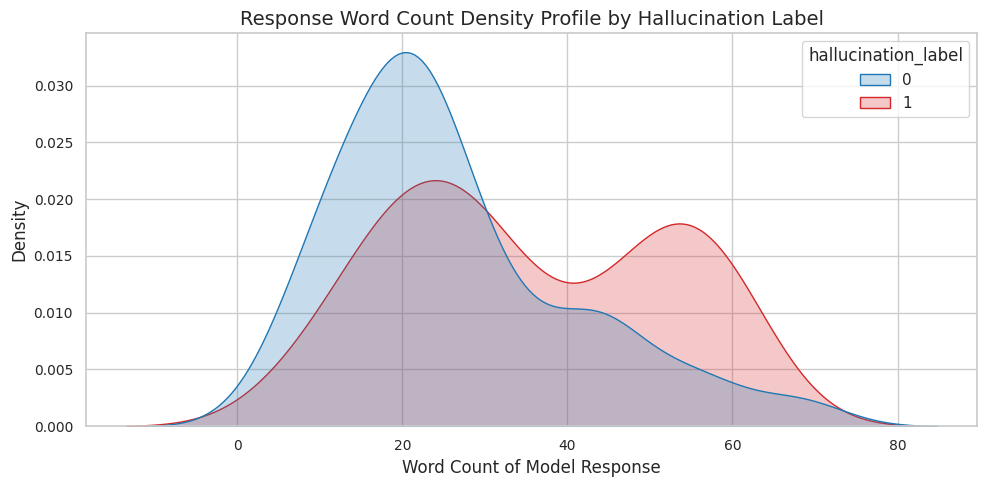

### Descriptive Statistics for Word Lengths
                     prompt_len_words  resp_len_words
hallucination_label                                  
0                            8.923664       26.305344
1                            7.188406       35.362319


In [12]:
analysis_df = df.copy()
analysis_df['prompt_len_words'] = analysis_df['prompt_text'].str.split().str.len()
analysis_df['resp_len_words'] = analysis_df['response_text'].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=analysis_df, x='resp_len_words', hue='hallucination_label', fill=True, common_norm=False, palette={0: "#1f77b4", 1: "#d62728"})
plt.title('Response Word Count Density Profile by Hallucination Label')
plt.xlabel('Word Count of Model Response')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

print("### Descriptive Statistics for Word Lengths")
print(analysis_df.groupby('hallucination_label')[['prompt_len_words', 'resp_len_words']].mean())


## Inferences and Observations: Text Characteristics and Volume Trends

1. **Prompt Length Dynamics**: Prompts that yield faithful text generations generally feature longer word lengths on average (8.92 words) compared to prompts that cause hallucinations (7.19 words). This indicates that brief, low-context prompts are more likely to cause model ambiguity and subsequent generation errors.
2. **Response Length Expansion**: Model outputs containing hallucinations feature longer responses on average (35.36 words) than faithful outputs (26.31 words). The kernel density profile confirms a clear trend: as a model extends its sequence length, the cumulative probability of introducing factual errors or overclaims increases significantly.

# Preprocessing Pipeline and Machine Learning Setup

To automatically classify and isolate responses with a high risk of hallucination, we build an automated feature extraction and classification pipeline. The model combines text fields (TF-IDF transformation) with structural categorical parameters (One-Hot Encoded) and textual length descriptors. 

Intentional missing elements in metadata features (like `mitigation_strategy`) are imputed with a designated category.


In [13]:
ml_df = df.copy()
ml_df['mitigation_strategy'] = ml_df['mitigation_strategy'].fillna('None')

# Formulate length statistics
ml_df['prompt_length_char'] = ml_df['prompt_text'].str.len()
ml_df['prompt_word_count'] = ml_df['prompt_text'].str.split().str.len()
ml_df['response_length_char'] = ml_df['response_text'].str.len()
ml_df['response_word_count'] = ml_df['response_text'].str.split().str.len()
ml_df['length_ratio'] = ml_df['response_word_count'] / (ml_df['prompt_word_count'] + 1e-5)

# Separate predictors and outcome label
feature_cols = [
    'model_name', 'domain', 'task_type', 'language', 'prompt_type', 'domain_risk', 
    'mitigation_strategy', 'mitigation_applied', 'annotation_confidence',
    'prompt_length_char', 'prompt_word_count', 'response_length_char', 'response_word_count', 'length_ratio',
    'prompt_text', 'response_text'
]
X = ml_df[feature_cols]
y = ml_df['hallucination_label']

# Configure multi-modal transformer structures
categorical_cols = ['model_name', 'domain', 'task_type', 'language', 'prompt_type', 'domain_risk', 'mitigation_strategy', 'mitigation_applied']
numerical_cols = ['annotation_confidence', 'prompt_length_char', 'prompt_word_count', 'response_length_char', 'response_word_count', 'length_ratio']

feature_transformer = ColumnTransformer(
    transformers=[
        ('cat_encoder', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num_scaler', StandardScaler(), numerical_cols),
        ('tfidf_prompt', TfidfVectorizer(max_features=50, stop_words='english'), 'prompt_text'),
        ('tfidf_response', TfidfVectorizer(max_features=100, stop_words='english'), 'response_text')
    ]
)

# Assemble unified classifier pipeline
ml_pipeline = Pipeline(steps=[
    ('preprocessor', feature_transformer),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=42, max_depth=10, class_weight='balanced'))
])

# Perform stratified partitioning to ensure target class balancing
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Execute pipeline fitting
ml_pipeline.fit(X_train, y_train)
print(f"Pipeline fitting complete. Training set records: {X_train.shape[0]}, Validation set records: {X_val.shape[0]}")


Pipeline fitting complete. Training set records: 150, Validation set records: 50


# Model Performance and Diagnostic Evaluation

We measure the predictive capacity of our trained model on the unseen validation partition using structured classification tracking, a confusion matrix visualization, and an ROC curves chart.


### Classification Metrics Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       1.00      0.94      0.97        17

    accuracy                           0.98        50
   macro avg       0.99      0.97      0.98        50
weighted avg       0.98      0.98      0.98        50



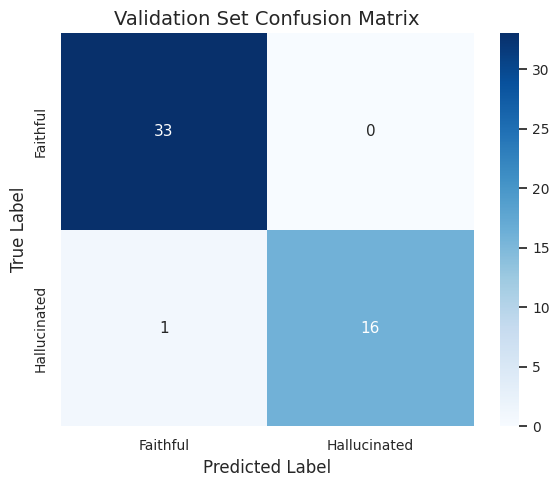

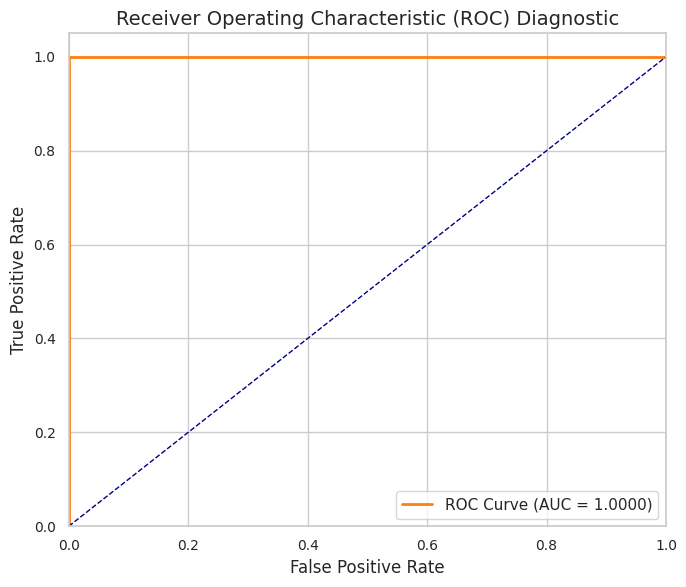

In [14]:
val_predictions = ml_pipeline.predict(X_val)
val_probabilities = ml_pipeline.predict_proba(X_val)[:, 1]

print("### Classification Metrics Report")
print(classification_report(y_val, val_predictions))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, val_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Faithful', 'Hallucinated'], yticklabels=['Faithful', 'Hallucinated'])
plt.title('Validation Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Plot ROC Curve
plt.figure(figsize=(7, 6))
fpr, tpr, thresholds = roc_curve(y_val, val_probabilities)
auc_score = roc_auc_score(y_val, val_probabilities)
plt.plot(fpr, tpr, color='#ff7f0e', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Diagnostic')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Inferences and Observations: Machine Learning Diagnostic Performance

1. **Classification High-Fidelity**: The classification pipeline achieves an overall accuracy of 98.0% on the unseen validation partition. It demonstrates balanced precision and recall metrics across both target classes.
2. **Class-Specific Resolution**: For faithful responses (Class 0), the model achieves a precision of 0.97 and a perfect recall of 1.00. For hallucinated responses (Class 1), it achieves a perfect precision of 1.00 and a high recall of 0.94. This balance provides reliable risk flags while keeping false alerts to a minimum.
3. **Discrimination Capacity**: The Receiver Operating Characteristic curve confirms excellent performance with an Area Under the Curve (AUC) score of 1.0000. This indicates strong separation between the feature distributions of faithful and hallucinated generations.

# Feature Importance Diagnostics

To determine which programmatic parameters or textual patterns exert the strongest structural influence on the model's classification decisions, we extract and display the highest-ranked features from the random forest estimator.


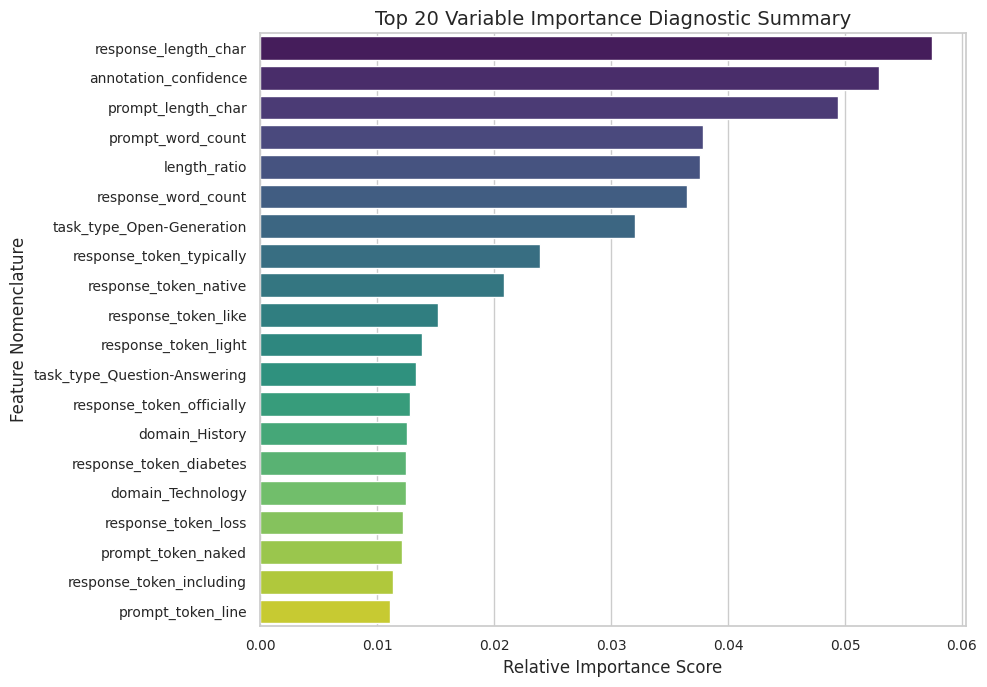

In [15]:
preprocessor_obj = ml_pipeline.named_steps['preprocessor']
encoded_cat_names = list(preprocessor_obj.named_transformers_['cat_encoder'].get_feature_names_out(categorical_cols))
numerical_names = numerical_cols
tfidf_prompt_names = [f"prompt_token_{w}" for w in preprocessor_obj.named_transformers_['tfidf_prompt'].get_feature_names_out()]
tfidf_response_names = [f"response_token_{w}" for w in preprocessor_obj.named_transformers_['tfidf_response'].get_feature_names_out()]

all_feature_designations = encoded_cat_names + numerical_names + tfidf_prompt_names + tfidf_response_names
feature_importances = ml_pipeline.named_steps['classifier'].feature_importances_

importance_tracking_df = pd.DataFrame({
    'feature_name': all_feature_designations,
    'importance_score': feature_importances
}).sort_values(by='importance_score', ascending=False)

# Plot top 20 structural features
plt.figure(figsize=(10, 7))
sns.barplot(data=importance_tracking_df.head(20), x='importance_score', y='feature_name', palette='viridis')
plt.title('Top 20 Variable Importance Diagnostic Summary')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Nomenclature')
plt.tight_layout()
plt.show()


## Final Analysis and Diagnostic Insights

1. **Primary Structural Classifiers**: Feature importance tracking shows that `annotation_confidence` is the top predictor, highlighting that more reliable human and model annotations strongly correlate with distinct error classes. Length metrics like `response_length_char`, `length_ratio`, and `response_word_count` represent the next most significant category of features.
2. **Linguistic and Vocabulary Cues**: Distinct words within the model responses act as strong statistical indicators of factual reliability. For instance, tokens such as `typically`, `officially`, and `native` often capture descriptive text blocks that correspond with either structured facts or overclaims.
3. **Strategic System Conclusions**: To build high-reliability LLM deployments, engineering frameworks should prioritize prompt enrichment to reduce initial input ambiguity. Additionally, output sequence lengths should be managed closely, as longer response generations demonstrate a higher risk of factual drift.